In [2]:
#!unzip imagewoof200.zip

In [3]:
from pathlib import Path

In [4]:
data_path = Path("")
image_path = data_path / "imagewoof200"

In [5]:
import os

In [7]:
def show_data(data_dir):
  for dirpath, dirnames, filenames in os.walk(data_dir):
    print(f"# of directories in {len(dirnames)} and {len(filenames)} images in {dirpath}")

In [8]:
show_data(image_path)

# of directories in 2 and 0 images in imagewoof200
# of directories in 10 and 0 images in imagewoof200/train
# of directories in 0 and 200 images in imagewoof200/train/border_terrier
# of directories in 0 and 200 images in imagewoof200/train/english_foxhound
# of directories in 0 and 200 images in imagewoof200/train/dingo
# of directories in 0 and 200 images in imagewoof200/train/beagle
# of directories in 0 and 200 images in imagewoof200/train/australian_terrier
# of directories in 0 and 200 images in imagewoof200/train/old_english_sheepdog
# of directories in 0 and 200 images in imagewoof200/train/samoyed
# of directories in 0 and 200 images in imagewoof200/train/rhodesian_ridgeback
# of directories in 0 and 200 images in imagewoof200/train/golden_retriever
# of directories in 0 and 200 images in imagewoof200/train/shih_tzu
# of directories in 10 and 0 images in imagewoof200/test
# of directories in 0 and 48 images in imagewoof200/test/border_terrier
# of directories in 0 and 48 imag

In [9]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [10]:
train_dir

PosixPath('imagewoof200/train')

In [11]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch

In [12]:
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [13]:
def create_data(
    train_dir: str,
    test_dir: str,
    transorm: transforms.Compose,
    batch_size: int
):
  train_data = datasets.ImageFolder(root=train_dir, transform=transorm)
  test_data = datasets.ImageFolder(root=test_dir, transform=transorm)

  class_names = train_data.classes

  train_dataloader = DataLoader(
      dataset=train_data,
      batch_size=batch_size,
      shuffle=True
  )
  test_dataloader = DataLoader(
      dataset=test_data,
      batch_size=batch_size,
      shuffle=False
  )
  return train_dataloader, test_dataloader, class_names

In [14]:
train_dataloader, test_dataloader, class_names = create_data(
    train_dir=train_dir,
    test_dir=test_dir,
    transorm=manual_transforms,
    batch_size=32
)

In [15]:
train_dataloader

In [16]:
test_dataloader

In [17]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [18]:
import torchvision

In [19]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [20]:
auto_transforms = weights.transforms()

In [21]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [22]:
train_dataloader, test_dataloader, class_names = create_data(
    train_dir=train_dir,
    test_dir=test_dir,
    transorm=auto_transforms,
    batch_size=32
)

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [24]:
device

'cuda'

In [25]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 176MB/s]


In [26]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [27]:
!pip install torchinfo

In [28]:
from torchinfo import summary

In [29]:
summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names = ["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        True
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        True
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        True
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        864                       True
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        64                        True
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential: 2-2  

In [30]:
for param in model.features.parameters():
  param.requires_grad = False

In [31]:
summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names = ["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 1000]                --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [32]:
from torch import nn

In [33]:
len(class_names)

10

In [43]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
).to(device)

Orijinal olan EfficentNetB0'ın sadece son katmanınındaki çıktı sayısını kendi çıktı sayım ile değiştirdim. Geri kalan parametreleri aynen yazdım.

In [35]:
summary(
    model=model,
    input_size=(32, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "trainable"],
)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 10]                  --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [44]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [45]:
def calculate_accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [46]:
def train(model: nn.Module,
          dataloader: torch.utils.data.DataLoader,
          loss_fn: nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          acc_fn):
  model.train()
  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    train_acc += acc_fn(y, y_pred.argmax(dim=1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [47]:
def test(model: nn.Module,
         dataloader: torch.utils.data.DataLoader,
         loss_fn: nn.Module,
         device,
         acc_fn):
  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)

      loss = loss_fn(y_pred, y)
      test_loss += loss.item()
      test_acc += acc_fn(y, y_pred.argmax(dim=1))

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
  return test_loss, test_acc

In [48]:
def train_test_step(
    model: nn.Module,
    train_dataloader: torch.utils.data.DataLoader,
    test_dataloader: torch.utils.data.DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int,
    acc_fn = calculate_accuracy
):
  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }

  for epoch in range(epochs):
    train_loss, train_acc = train(model=model,
                                dataloader=train_dataloader,
                                loss_fn=loss_fn,
                                optimizer=optimizer,
                                device=device,
                                acc_fn=acc_fn)
    test_loss, test_acc = test(model=model,
                              dataloader=test_dataloader,
                              loss_fn=loss_fn,
                              device=device,
                              acc_fn=acc_fn)

    print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    results["train_loss"].append(train_loss if isinstance(train_loss, torch.Tensor) else train_loss)
    results["train_acc"].append(train_acc if isinstance(train_acc, torch.Tensor) else train_acc)
    results["test_loss"].append(test_loss if isinstance(test_loss, torch.Tensor) else test_loss)
    results["test_acc"].append(test_acc if isinstance(test_acc, torch.Tensor) else test_acc)

  return results


In [49]:
model_results = train_test_step(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    epochs=10
)

Epoch: 1 | Train Loss: 1.4151 | Train Acc: 67.71% | Test Loss: 0.7639 | Test Acc: 84.79%
Epoch: 2 | Train Loss: 0.6962 | Train Acc: 84.28% | Test Loss: 0.5311 | Test Acc: 87.29%
Epoch: 3 | Train Loss: 0.5331 | Train Acc: 87.45% | Test Loss: 0.4531 | Test Acc: 87.50%
Epoch: 4 | Train Loss: 0.4592 | Train Acc: 88.89% | Test Loss: 0.4063 | Test Acc: 89.17%
Epoch: 5 | Train Loss: 0.4135 | Train Acc: 89.09% | Test Loss: 0.3914 | Test Acc: 89.38%
Epoch: 6 | Train Loss: 0.3641 | Train Acc: 90.48% | Test Loss: 0.3769 | Test Acc: 89.17%
Epoch: 7 | Train Loss: 0.3412 | Train Acc: 91.12% | Test Loss: 0.3668 | Test Acc: 88.75%
Epoch: 8 | Train Loss: 0.3136 | Train Acc: 92.26% | Test Loss: 0.3516 | Test Acc: 89.79%
Epoch: 9 | Train Loss: 0.3044 | Train Acc: 91.72% | Test Loss: 0.3604 | Test Acc: 89.79%
Epoch: 10 | Train Loss: 0.2761 | Train Acc: 92.31% | Test Loss: 0.3484 | Test Acc: 89.79%


In [50]:
from typing import List, Tuple
from PIL import Image

In [56]:
def transform_predict(model: nn.Module,
                      image_path: str,
                      class_names: List[str],
                      device: torch.device,
                      image_size: Tuple[int, int] = (224, 224),
                      transform: torchvision.transforms = None):
  img = Image.open(image_path)

  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
  model.to(device)
  model.eval()

  with torch.inference_mode():
    transformed_image = image_transform(img).unsqueeze(dim=0)
    target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [54]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [62]:
custom_image_path = "images.jpg"

In [64]:
import matplotlib.pyplot as plt

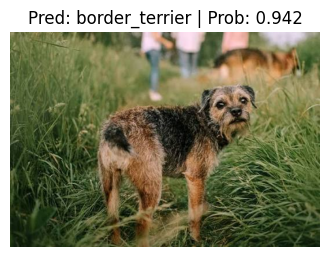

In [65]:
transform_predict(
    model=model,
    image_path=custom_image_path,
    class_names=class_names,
    device=device
)